In [15]:
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

In [16]:
titanic= sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [17]:
# Missing Values 
print(titanic.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [18]:
data= titanic[['age','fare','pclass', 'sex']]
data= pd.get_dummies(data, drop_first=True)
data.head()

,age,fare,pclass,sex_male
0,22.0,7.2500,3,True
1,38.0,71.2833,1,False
2,26.0,7.9250,3,False
3,35.0,53.1000,1,False
4,35.0,8.0500,3,True


In [19]:
imputer= IterativeImputer(max_iter=10, random_state=0)
data_imputed= pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

In [20]:
print('Datos originales')
print(data.head(30))
print('Datos imputados')
print(data_imputed.head(30))

Datos originales
     age      fare  pclass  sex_male
0   22.0    7.2500       3      True
1   38.0   71.2833       1     False
2   26.0    7.9250       3     False
3   35.0   53.1000       1     False
4   35.0    8.0500       3      True
5    NaN    8.4583       3      True
6   54.0   51.8625       1      True
7    2.0   21.0750       3      True
8   27.0   11.1333       3     False
9   14.0   30.0708       2     False
10   4.0   16.7000       3     False
11  58.0   26.5500       1     False
12  20.0    8.0500       3      True
13  39.0   31.2750       3      True
14  14.0    7.8542       3     False
15  55.0   16.0000       2     False
16   2.0   29.1250       3      True
17   NaN   13.0000       2      True
18  31.0   18.0000       3     False
19   NaN    7.2250       3     False
20  35.0   26.0000       2      True
21  34.0   13.0000       2      True
22  15.0    8.0292       3     False
23  28.0   35.5000       1      True
24   8.0   21.0750       3     False
25  38.0   31.3875   

Exercise 1:

Use MICE on the life-expectancy dataset https://www.kaggle.com/datasets/kumarajarchi/life-expectancy-who

In [21]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("kumarajarshi/life-expectancy-who")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kakop\.cache\kagglehub\datasets\kumarajarshi\life-expectancy-who\versions\1


In [22]:
csv_path = os.path.join(path, "Life Expectancy Data.csv")
df = pd.read_csv(csv_path)
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [23]:
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
 BMI                                34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


In [24]:
data = df[['Alcohol', 'Hepatitis B', 'Income composition of resources', 'Schooling']]
data= pd.get_dummies(data, drop_first=True)
data.head()

,Alcohol,Hepatitis B,Income composition of resources,Schooling
0,0.01,65.0,0.479,10.1
1,0.01,62.0,0.476,10.0
2,0.01,64.0,0.470,9.9
3,0.01,67.0,0.463,9.8
4,0.01,68.0,0.454,9.5


In [25]:
from fancyimpute import IterativeImputer

mice_imputer = IterativeImputer()
df_imputed = pd.DataFrame(mice_imputer.fit_transform(data), columns=data.columns)

# Replace the original columns with imputed values
df[df_imputed.columns] = df_imputed

# Check if there are any missing values left
print(df.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                              0
percentage expenditure               0
Hepatitis B                          0
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources      0
Schooling                            0
dtype: int64


In [26]:
print('Datos originales')
print(data.head(30))
print('Datos imputados')
print(df_imputed.head(30))

Datos originales
    Alcohol  Hepatitis B  Income composition of resources  Schooling
0      0.01         65.0                            0.479       10.1
1      0.01         62.0                            0.476       10.0
2      0.01         64.0                            0.470        9.9
3      0.01         67.0                            0.463        9.8
4      0.01         68.0                            0.454        9.5
5      0.01         66.0                            0.448        9.2
6      0.01         63.0                            0.434        8.9
7      0.03         64.0                            0.433        8.7
8      0.02         63.0                            0.415        8.4
9      0.03         64.0                            0.405        8.1
10     0.02         66.0                            0.396        7.9
11     0.02         67.0                            0.381        6.8
12     0.01         65.0                            0.373        6.5
13     0.01      

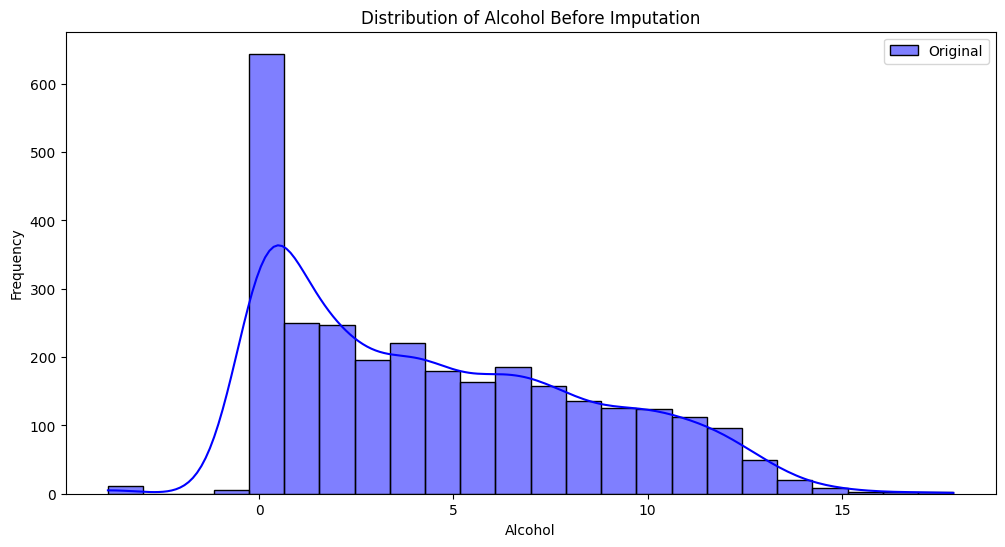

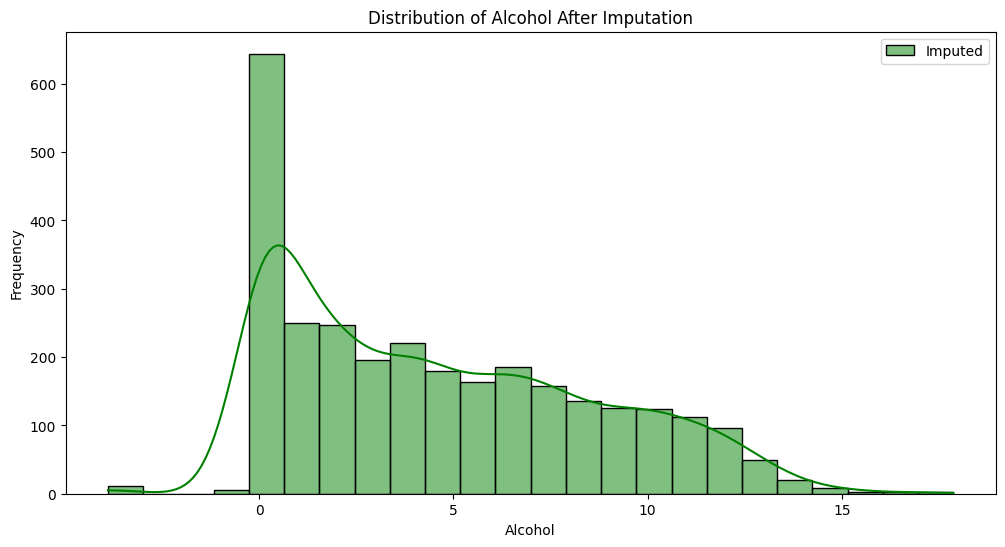

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot before imputation
plt.figure(figsize=(12, 6))
sns.histplot(df['Alcohol'], kde=True, color='blue', label='Original')
plt.title('Distribution of Alcohol Before Imputation')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot after imputation
plt.figure(figsize=(12, 6))
sns.histplot(df_imputed['Alcohol'], kde=True, color='green', label='Imputed')
plt.title('Distribution of Alcohol After Imputation')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Exercise 2:

Use MICE on the Planets (seaborn) dataset to fill in missing values.

In [28]:
df = sns.load_dataset("planets")

# Check missing values
print(df.isnull().sum())

method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64


In [29]:
data = df[['orbital_period', 'mass', 'distance']]
data= pd.get_dummies(data, drop_first=True)
data.head()

,orbital_period,mass,distance
0,269.300,7.10,77.40
1,874.774,2.21,56.95
2,763.000,2.60,19.84
3,326.030,19.40,110.62
4,516.220,10.50,119.47


In [30]:
from fancyimpute import IterativeImputer

mice_imputer = IterativeImputer()
df_imputed = pd.DataFrame(mice_imputer.fit_transform(data), columns=data.columns)

# Replace the original columns with imputed values
df[df_imputed.columns] = df_imputed

# Check if there are any missing values left
print(df.isnull().sum())

method            0
number            0
orbital_period    0
mass              0
distance          0
year              0
dtype: int64


In [31]:
print('Datos originales')
print(data.head(30))
print('Datos imputados')
print(df_imputed.head(30))

Datos originales
    orbital_period    mass  distance
0       269.300000   7.100     77.40
1       874.774000   2.210     56.95
2       763.000000   2.600     19.84
3       326.030000  19.400    110.62
4       516.220000  10.500    119.47
5       185.840000   4.800     76.39
6      1773.400000   4.640     18.15
7       798.500000     NaN     21.41
8       993.300000  10.300     73.10
9       452.800000   1.990     74.79
10      883.000000   0.860     74.79
11      335.100000   9.880     39.43
12      479.100000   3.880     97.28
13     1078.000000   2.530     14.08
14     2391.000000   0.540     14.08
15    14002.000000   1.640     14.08
16        4.230785   0.472     15.36
17       14.651000   0.800     12.53
18       44.380000   0.165     12.53
19     4909.000000   3.530     12.53
20        0.736540     NaN     12.53
21      261.200000   0.172     12.53
22        4.215000   0.016      8.52
23       38.021000   0.057      8.52
24      123.010000   0.072      8.52
25      116.688400   

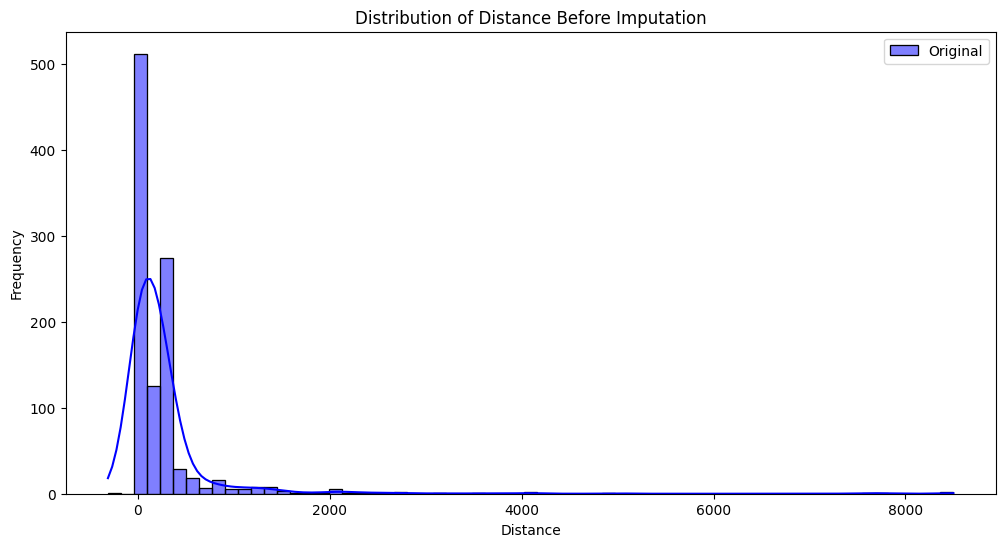

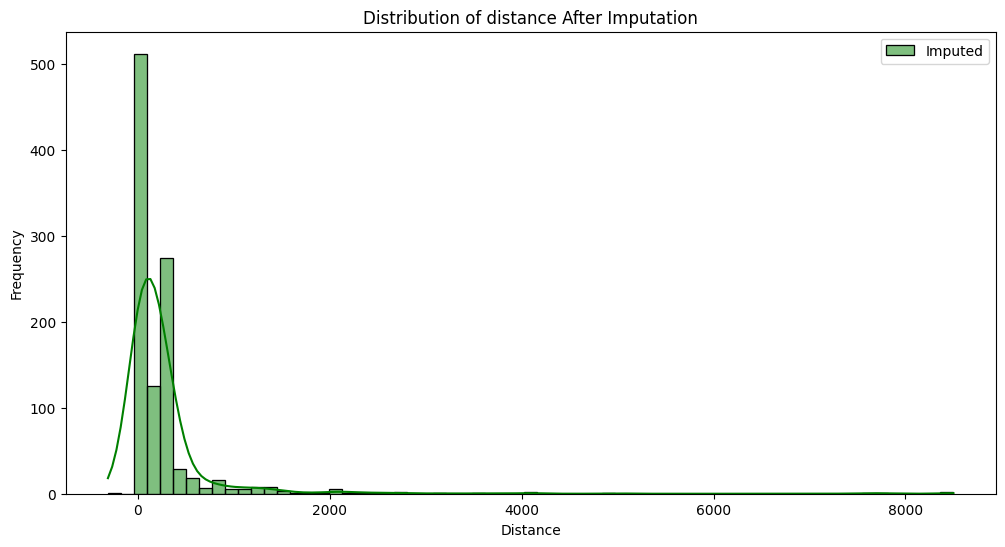

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot before imputation
plt.figure(figsize=(12, 6))
sns.histplot(df['distance'], kde=True, color='blue', label='Original')
plt.title('Distribution of Distance Before Imputation')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot after imputation
plt.figure(figsize=(12, 6))
sns.histplot(df_imputed['distance'], kde=True, color='green', label='Imputed')
plt.title('Distribution of distance After Imputation')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()